# **El entrenamiento de Naruto Uzumaki**

In [ ]:
import threading
from random import randint,uniform
from time import sleep,perf_counter
import matplotlib.pyplot as plt

#**Funcion de entrenamiento**
Para evitar usar sincro/comunicacion, cada thread tiene su posicion asignada en una lista donde guarda el resultado de su entrenamiento.   
Al final se suman para obtener el nivel alcanzado.

In [ ]:
def training(clones):
  result = [0]*clones

  def train(clone_number):
    nonlocal result
    chakra = 5+randint(0,5)
    level = randint(0,1)
    wait_time = uniform(0.1,0.2)
    for _ in range(chakra):
      result[clone_number]+=level
      sleep(wait_time)

  threads = list()

  for clone_number in range(clones):
    threads.append(threading.Thread(target=train,args=(clone_number,)))
    threads[clone_number].start()

  for thread in threads:
    thread.join()

  return sum(result)

# **Tiempo de ejecucion**
Se mide el tiempo de ejecucion para distintas cantidades de clones. Nota: Wall time = tiempo transcurrido real.

In [ ]:
%%time
print ("Nivel alcanzado:",training(5),end='\n')

Nivel alcanzado: 18
CPU times: user 11.2 ms, sys: 3.01 ms, total: 14.2 ms
Wall time: 1.73 s


In [ ]:
%%time
print ("Nivel alcanzado:",training(10),end='\n')

Nivel alcanzado: 37
CPU times: user 15.2 ms, sys: 6.03 ms, total: 21.2 ms
Wall time: 1.68 s


In [ ]:
%%time
print ("Nivel alcanzado:",training(15),end='\n')

Nivel alcanzado: 55
CPU times: user 19.4 ms, sys: 46 µs, total: 19.4 ms
Wall time: 1.52 s


In [ ]:
%%time
print ("Nivel alcanzado:",training(20),end='\n')

Nivel alcanzado: 85
CPU times: user 21.6 ms, sys: 3.32 ms, total: 24.9 ms
Wall time: 1.67 s


In [ ]:
%%time
print ("Nivel alcanzado:",training(500),end='\n')

Nivel alcanzado: 1910
CPU times: user 229 ms, sys: 156 ms, total: 385 ms
Wall time: 2.96 s


In [ ]:
%%time
print ("Nivel alcanzado:",training(5000),end='\n')

Nivel alcanzado: 18750
CPU times: user 2.45 s, sys: 1.39 s, total: 3.85 s
Wall time: 10.5 s


# **Grafico: Tiempo transcurrido en funcion de la cantidad de clones**

Calculo los tiempos de ejecucion para entrenamientos con distintas cantidades de clones, los obtengo midiendo la diferencia en tiempo antes y despues de ejecutar.

In [ ]:
clone_range = range(10,1010,10)
times = dict()

for clone_number in clone_range:
  start = perf_counter()
  training(clone_number)
  times[clone_number] = perf_counter()-start

Creo y muestro el grafico

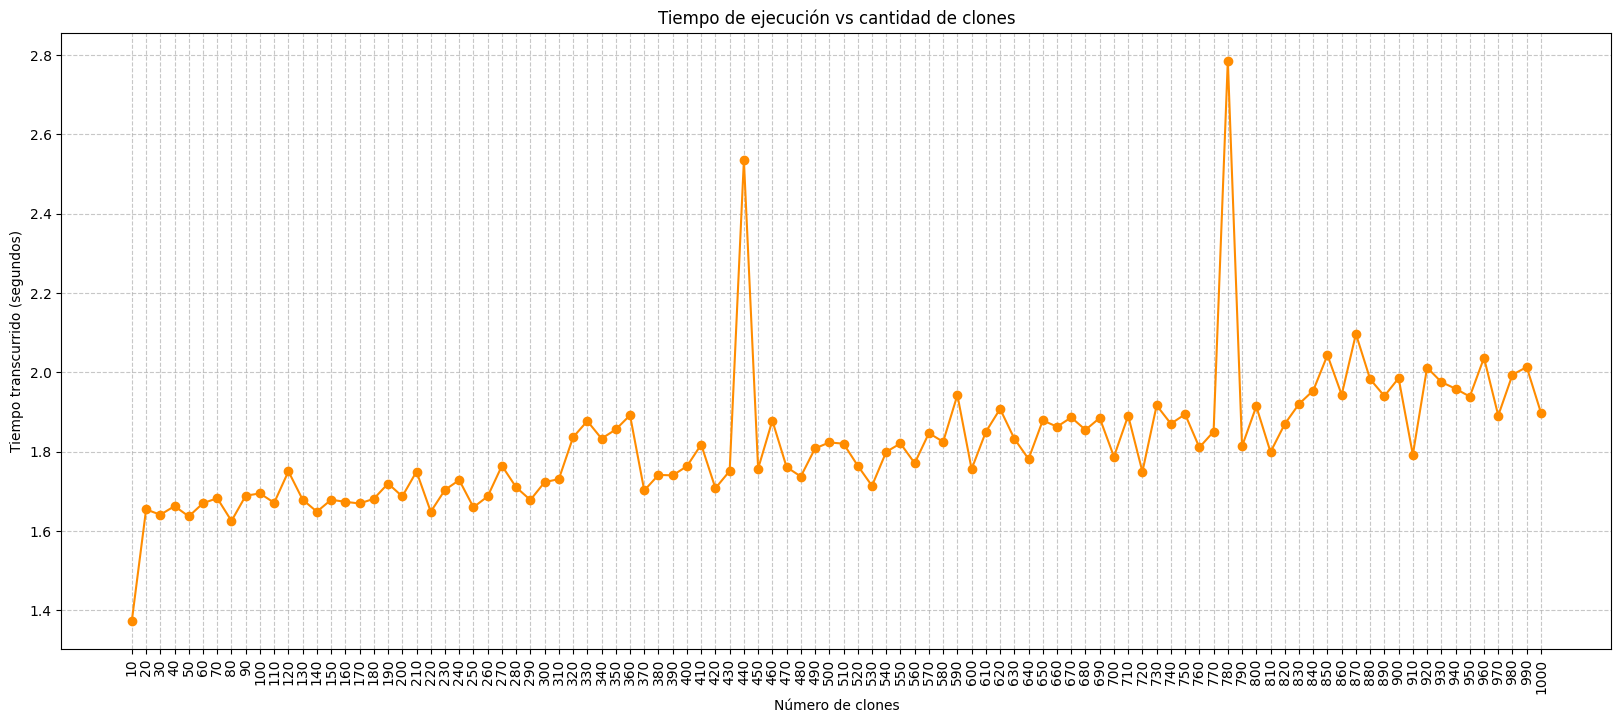

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(times.keys(), times.values(), marker='o', color='darkorange')
plt.xlabel('Número de clones')
plt.ylabel('Tiempo transcurrido (segundos)')
plt.title('Tiempo de ejecución vs cantidad de clones')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(list(clone_range), rotation=90)
plt.show()

En el grafico se observa que, salvo algunos outliers, el tiempo de ejecucion varia muy poco a medida que aumenta la cantidad de clones. Esto se debe a que cada nuevo clon que se ejecuta, lo hace concurrentemente. En las pruebas individuales se aprecia que el puntaje aumenta considerablemente a medida que lo hacen los clones. Por lo tanto, la cantidad optima de clones seria la maxima posible.



---



